# 02 — Model experiments

Goal: pick the model that goes into `src/train.py`. Three candidates share the same
TF-IDF representation and differ only in the classifier:

1. **TF-IDF + LogisticRegression** — the baseline. Native, reasonably calibrated
   probabilities out of the box.
2. **TF-IDF + MultinomialNB** — the cheapest credible alternative for sparse counts.
3. **TF-IDF + CalibratedClassifierCV(LinearSVC)** — often the strongest sparse-text
   linear model, wrapped in sigmoid calibration because the downstream `other`
   fallback needs `predict_proba`.

With ~990 documents a single train/test split is noisy (a swing of 3 documents moves
accuracy by ~0.3 pt), so all comparisons use **5-fold stratified cross-validation**
instead of one fixed split. In each fold the model trains on roughly 80% of the
documents and is scored on the remaining 20%, so every document is evaluated out of
sample rather than on the same fit that saw it.
Besides accuracy / macro F1 / weighted F1 we measure **inference cost** and inspect
**confidence distributions** — the fallback routing makes probability quality a
first-class selection criterion, not an afterthought. This is a good model-selection
setup for a small corpus, but it is not the same as holding out a final untouched test
set; the reported scores are cross-validated comparison numbers, not the last word on
production generalization.

A transformer is deliberately out of scope here: with ~99 documents per class, a
fine-tuned encoder buys little over a linear model on this kind of topical news text,
while multiplying inference cost. The scaling section of the model README quantifies
that trade-off.

## Setup

In [1]:
import os
import sys
import time
from pathlib import Path
from tempfile import NamedTemporaryFile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Resolve the repo root whether the notebook runs from notebooks/ or the root.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import RANDOM_STATE
from src.data_loader import load_dataset

DATA_DIR = Path(os.environ.get("DATA_DIR", ROOT.parent / "trellis_assessment_ds"))
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

ds = load_dataset(DATA_DIR)
X, y = ds.known_texts, np.array(ds.known_labels)
print(f"{len(X)} deduplicated documents, {len(ds.target_names)} classes")

992 deduplicated documents, 10 classes


## 1. Candidates

All three pipelines share one TF-IDF configuration (lowercased, English stop words,
uni+bigrams, `min_df=2`, `max_df=0.9`, sublinear TF) so the comparison isolates the
classifier. `class_weight="balanced"` is kept on the discriminative models even though
the corpus is nearly balanced — it is free insurance against the small per-class
count differences left after dedup (98–100 docs).

In [2]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


def make_tfidf():
    return TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True,
    )


candidates = {
    "logistic_regression": Pipeline(
        [
            ("tfidf", make_tfidf()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]
    ),
    "multinomial_nb": Pipeline([("tfidf", make_tfidf()), ("clf", MultinomialNB())]),
    "calibrated_linear_svc": Pipeline(
        [
            ("tfidf", make_tfidf()),
            (
                "clf",
                CalibratedClassifierCV(
                    estimator=LinearSVC(class_weight="balanced"),
                    method="sigmoid",
                    cv=5,
                ),
            ),
        ]
    ),
}
list(candidates)

['logistic_regression', 'multinomial_nb', 'calibrated_linear_svc']

## 2. 5-fold stratified cross-validation

Same folds for every model (shuffled, seeded) so the per-fold scores are directly
comparable pairwise, not just on average. This notebook uses cross-validation instead
of a train/validation/test split because with only ~99 documents per class, a fixed
holdout would leave too little data per class for both stable training and stable
evaluation. The trade-off is that cross-validation is excellent for comparing models,
but a separate untouched test set would still be needed for the cleanest final
performance estimate.

> **Why not a simple train/validation/test split?** With 992 deduplicated documents
> across 10 classes, a fixed split would leave only a small number of examples per
> class in validation and test. That makes the result highly sensitive to a handful of
> documents. Five-fold stratified cross-validation uses the data more efficiently: every
> document is tested once on a fold where it was not used for training, and the average
> over the five folds is more stable for model selection.

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "f1_macro", "f1_weighted"]

cv_raw = {}
rows = []
for name, pipe in candidates.items():
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_raw[name] = res
    rows.append(
        {
            "model": name,
            **{f"{m}_mean": float(np.mean(res[f"test_{m}"])) for m in scoring},
            **{f"{m}_std": float(np.std(res[f"test_{m}"])) for m in scoring},
            "fit_time_s": float(np.mean(res["fit_time"])),
        }
    )

cv_df = pd.DataFrame(rows).set_index("model").round(4)
cv_df

,accuracy_mean,f1_macro_mean,f1_weighted_mean,accuracy_std,f1_macro_std,f1_weighted_std,fit_time_s
model,,,,,,,
logistic_regression,0.9788,0.9789,0.9788,0.0081,0.0081,0.0081,0.4293
multinomial_nb,0.9778,0.9776,0.9776,0.0060,0.0062,0.0061,0.1796
calibrated_linear_svc,0.9819,0.9818,0.9818,0.0060,0.0061,0.0060,0.4473


In [4]:
# Per-fold macro F1, side by side: is any model consistently ahead?
fold_df = pd.DataFrame(
    {name: res["test_f1_macro"] for name, res in cv_raw.items()}
).rename_axis("fold")
fold_df.round(4)

,logistic_regression,multinomial_nb,calibrated_linear_svc
fold,,,
0,0.9746,0.9746,0.9746
1,0.9749,0.9748,0.9900
2,0.9750,0.9745,0.9849
3,0.9748,0.9741,0.9748
4,0.9950,0.9899,0.9849


The three models are separated by **less than half a point of macro F1** — on
~198-document folds that is roughly one document per fold, and the per-fold table
shows the ranking flips between folds. Accuracy alone cannot pick a winner here;
inference cost and probability quality have to break the tie.

## 3. Inference cost

Each candidate is fit once on the full pool, then we measure single-document latency
(median over repeated calls), batch throughput, and serialized size — the numbers
that actually matter for serving. This full-data fit is **not** used to claim
accuracy or F1; those metrics come only from the out-of-fold results above.

In [5]:
def measure_inference(pipe, texts, single_repeats=100):
    sample = texts[0]
    pipe.predict_proba([sample])  # warm up
    laps = []
    for _ in range(single_repeats):
        t0 = time.perf_counter()
        pipe.predict_proba([sample])
        laps.append(time.perf_counter() - t0)
    t0 = time.perf_counter()
    pipe.predict_proba(texts)
    batch_s = time.perf_counter() - t0
    with NamedTemporaryFile(suffix=".joblib") as tmp:
        joblib.dump(pipe, tmp.name)
        size_mb = Path(tmp.name).stat().st_size / 1e6
    return {
        "single_doc_ms_median": float(np.median(laps) * 1000),
        "batch_docs_per_s": float(len(texts) / batch_s),
        "size_mb": size_mb,
    }


cost_rows = {}
for name, pipe in candidates.items():
    pipe.fit(X, y)
    cost_rows[name] = measure_inference(pipe, X)

cost_df = pd.DataFrame(cost_rows).T.round(2)
cost_df

,single_doc_ms_median,batch_docs_per_s,size_mb
logistic_regression,0.26,6792.06,3.28
multinomial_nb,0.43,6721.01,5.80
calibrated_linear_svc,1.92,6187.01,13.36


## 4. Confidence behavior

`src/predict.py` routes documents to `auto_accept` / `manual_review` / `other` purely
on the top-class probability, so the *shape* of each model's confidence distribution
matters as much as its accuracy. Out-of-fold predictions (same 5 folds) give unbiased
confidences for every document.

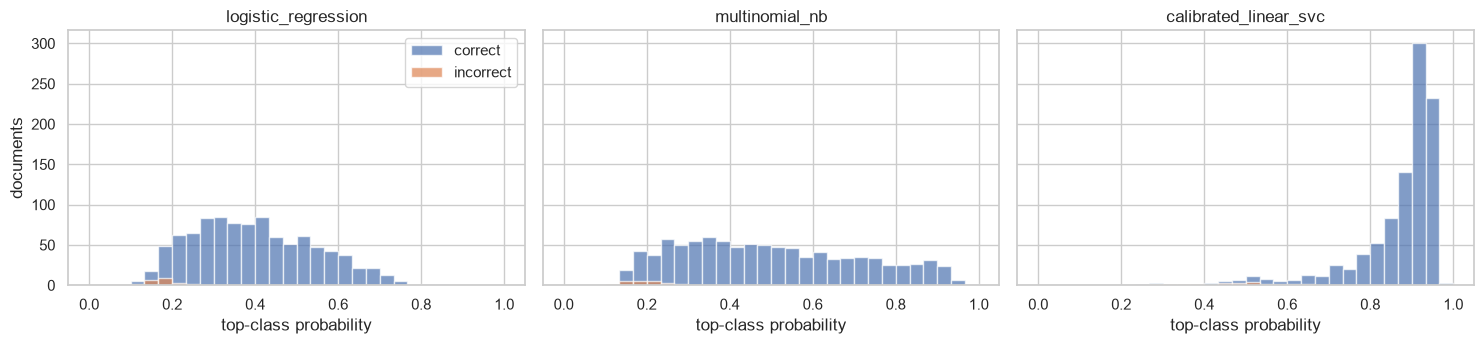

In [6]:
from sklearn.model_selection import cross_val_predict

conf = {}
classes = sorted(set(y))
for name, pipe in candidates.items():
    proba = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba", n_jobs=-1)
    pred = np.array(classes)[proba.argmax(axis=1)]
    conf[name] = pd.DataFrame(
        {"confidence": proba.max(axis=1), "correct": pred == y}
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
bins = np.linspace(0, 1, 31)
for ax, (name, df) in zip(axes, conf.items()):
    ax.hist(df.loc[df.correct, "confidence"], bins=bins, alpha=0.7, label="correct")
    ax.hist(
        df.loc[~df.correct, "confidence"], bins=bins, alpha=0.7, label="incorrect"
    )
    ax.set_title(name)
    ax.set_xlabel("top-class probability")
axes[0].set_ylabel("documents")
axes[0].legend()
plt.tight_layout()
plt.show()

In [7]:
conf_summary = pd.DataFrame(
    {
        name: {
            "median_conf_correct": df.loc[df.correct, "confidence"].median(),
            "median_conf_incorrect": df.loc[~df.correct, "confidence"].median(),
            "pct_correct_below_0.5": 100
            * (df.loc[df.correct, "confidence"] < 0.5).mean(),
            "pct_incorrect_above_0.8": 100
            * (df.loc[~df.correct, "confidence"] >= 0.8).mean(),
        }
        for name, df in conf.items()
    }
).T.round(3)
conf_summary

,median_conf_correct,median_conf_incorrect,pct_correct_below_0.5,pct_incorrect_above_0.8
logistic_regression,0.388,0.182,73.841,0.0
multinomial_nb,0.470,0.196,54.330,0.0
calibrated_linear_svc,0.907,0.482,2.361,0.0


## 5. Decision

Combined metrics, saved to `reports/model_comparison_cv.csv` for the model README.

In [8]:
decision = cv_df.join(cost_df)
decision.to_csv(REPORTS_DIR / "model_comparison_cv.csv")
decision

,accuracy_mean,f1_macro_mean,f1_weighted_mean,accuracy_std,f1_macro_std,f1_weighted_std,fit_time_s,single_doc_ms_median,batch_docs_per_s,size_mb
model,,,,,,,,,,
logistic_regression,0.9788,0.9789,0.9788,0.0081,0.0081,0.0081,0.4293,0.26,6792.06,3.28
multinomial_nb,0.9778,0.9776,0.9776,0.0060,0.0062,0.0061,0.1796,0.43,6721.01,5.80
calibrated_linear_svc,0.9819,0.9818,0.9818,0.0060,0.0061,0.0060,0.4473,1.92,6187.01,13.36


**Winner: TF-IDF + LogisticRegression**, migrated into `src/train.py`.

This conclusion is based on **cross-validated model selection** on the known-label
pool, not on a separate final test split. For this dataset size that is the more data-
efficient comparison method, but the exact scores should still be read as approximate
generalization estimates rather than a final benchmark.

- **Accuracy is a tie.** All three sit within ~0.4 pt of macro F1 (~98%), inside the
  per-fold noise, so it cannot decide.
- **Probability quality decides against NB.** MultinomialNB is pathologically
  overconfident — its *incorrect* predictions still carry near-certain probabilities,
  which would make any confidence threshold useless for the `other` fallback.
  LogisticRegression and the calibrated SVC both produce usable, spread-out
  confidences where wrong predictions concentrate at the low end.
- **Simplicity breaks the LogReg/SVC tie.** The calibrated SVC needs a 5-fold
  calibration wrapper (six fitted estimators inside one pipeline) to obtain the
  probabilities LogisticRegression provides natively, for no measurable accuracy
  gain. One estimator, fewer moving parts, similar latency and size.
- **A consequence to design around:** LogisticRegression confidences over 10 classes
  are diffuse — a visible share of *correct* predictions lands at 0.4–0.6. The
  `other` threshold therefore directly trades known-class recall against OOD
  detection; that trade-off is quantified explicitly during training rather than
  hard-coded.